# Tarefa: Classificadores Supervisionados — K-NN, Árvore de Decisão e Naive Bayes

**Aluno:** Cauê Reis

**Disciplina:** Mineração de Dados

## Dataset Wine — Identificando a Vinícola (Classe) a partir de Dados Químicos

**Objetivo:** Implementar os três classificadores estudados (K-NN, Árvore de Decisão e Naive Bayes) em um único conjunto de dados, avaliar o desempenho de cada um usando a métrica de **Acurácia** e compreender, na prática, o impacto dos hiperparâmetros no comportamento de cada modelo. Utiliza-se o **Dataset Wine** (dados químicos de amostras de vinho), no qual o objetivo é descobrir a qual vinícola (classe) cada amostra pertence a partir de 13 atributos químicos (teor alcoólico, flavanoides, intensidade de cor, prolina, etc.).

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 1. Carregamento dos Dados

In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['Vinicola'] = df['target'].map({0: 'Vinicola_0', 1: 'Vinicola_1', 2: 'Vinicola_2'})

print('Primeiras observacoes do dataset:')
display(df.head(10))

print(f'\nDimensoes: {df.shape[0]} amostras x {df.shape[1]-2} atributos')
print(f'Classes   : {list(wine.target_names)}')
print(f'\nDistribuicao das classes:')
print(df['Vinicola'].value_counts())

Primeiras observacoes do dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,Vinicola
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Vinicola_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Vinicola_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Vinicola_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Vinicola_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Vinicola_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,Vinicola_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,Vinicola_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,Vinicola_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,Vinicola_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,Vinicola_0



Dimensoes: 178 amostras x 13 atributos
Classes   : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Distribuicao das classes:
Vinicola
Vinicola_1    71
Vinicola_0    59
Vinicola_2    48
Name: count, dtype: int64


### 2. Análise Exploratória dos Dados

In [3]:
display(df[wine.feature_names].describe().round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


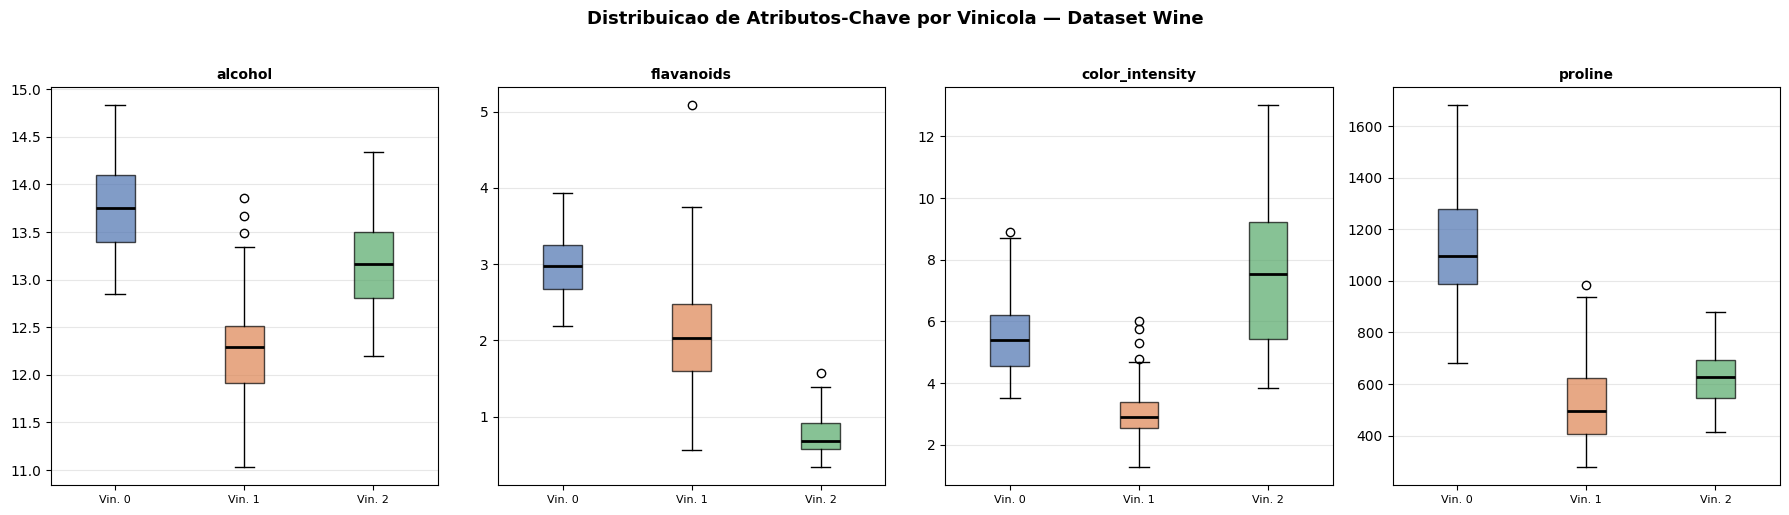

In [4]:
atributos_destaque = ['alcohol', 'flavanoids', 'color_intensity', 'proline']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
cores = {'Vinicola_0': '#4C72B0', 'Vinicola_1': '#DD8452', 'Vinicola_2': '#55A868'}

for ax, feature in zip(axes, atributos_destaque):
    grupos = [df[df['Vinicola'] == v][feature].values for v in cores]
    bp = ax.boxplot(grupos, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores.values()):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Vin. 0', 'Vin. 1', 'Vin. 2'], fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuicao de Atributos-Chave por Vinicola — Dataset Wine',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

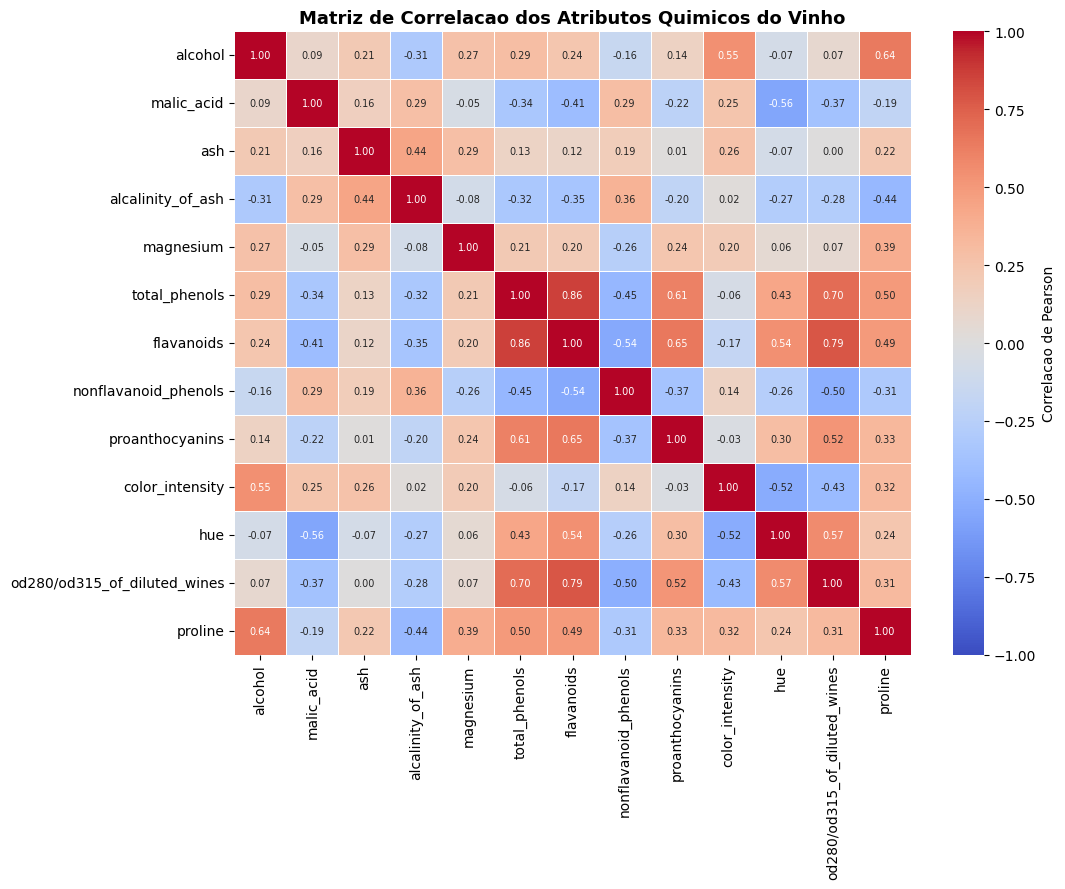

In [5]:
corr_matrix = df[wine.feature_names].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 7},
    cbar_kws={'label': 'Correlacao de Pearson'}
)
plt.title('Matriz de Correlacao dos Atributos Quimicos do Vinho', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Pré-processamento — Divisão Treino/Teste e Padronização

In [6]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'\nMedia pos-escala no treino (deve ser ~0):\n{X_train_scaled.mean(axis=0).round(2)}')
print(f'\nDesvio pos-escala no treino (deve ser ~1):\n{X_train_scaled.std(axis=0).round(2)}')

Treino: 124 amostras | Teste: 54 amostras

Media pos-escala no treino (deve ser ~0):
[ 0.  0.  0.  0. -0.  0.  0. -0.  0. -0.  0.  0. -0.]

Desvio pos-escala no treino (deve ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 4. Baseline — Os Três Classificadores com Parâmetros Padrão

Antes de mexer em qualquer hiperparâmetro, treina-se cada classificador com uma configuração de referência: **K-NN com k=5**, **Árvore de Decisão sem limite de profundidade** e **Naive Bayes** (que não exige nenhum ajuste técnico prévio).

In [7]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
acc_knn_base = accuracy_score(y_test, knn_base.predict(X_test_scaled))

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_scaled, y_train)
acc_dt_base = accuracy_score(y_test, dt_base.predict(X_test_scaled))

nb_base = GaussianNB()
nb_base.fit(X_train_scaled, y_train)
y_pred_nb = nb_base.predict(X_test_scaled)
acc_nb_base = accuracy_score(y_test, y_pred_nb)

df_baseline = pd.DataFrame({
    'Classificador': ['K-NN (k=5)', f'Arvore de Decisao (profundidade={dt_base.get_depth()}, sem limite)', 'Naive Bayes'],
    'Acuracia': [acc_knn_base, acc_dt_base, acc_nb_base]
}).sort_values('Acuracia', ascending=False).reset_index(drop=True)

print('Desempenho baseline dos tres classificadores (conjunto de teste):')
print(df_baseline.to_string(index=False, formatters={'Acuracia': '{:.4f}'.format}))

Desempenho baseline dos tres classificadores (conjunto de teste):
                                 Classificador Acuracia
                                   Naive Bayes   1.0000
Arvore de Decisao (profundidade=4, sem limite)   0.9630
                                    K-NN (k=5)   0.9444


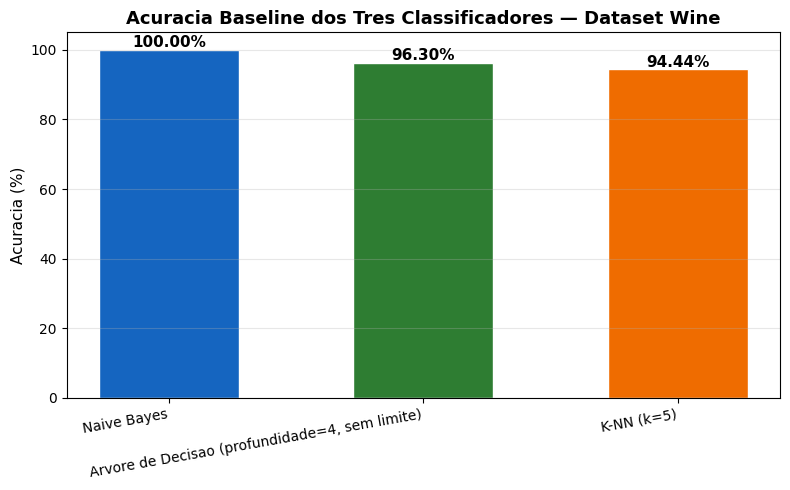

In [8]:
cores_base = ['#1565C0', '#2E7D32', '#EF6C00']

plt.figure(figsize=(8, 5))
bars = plt.bar(df_baseline['Classificador'], df_baseline['Acuracia'] * 100,
               color=cores_base, edgecolor='white', width=0.55)
for bar, val in zip(bars, df_baseline['Acuracia']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.7,
              f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.ylabel('Acuracia (%)', fontsize=11)
plt.ylim(0, 105)
plt.title('Acuracia Baseline dos Tres Classificadores — Dataset Wine', fontsize=13, fontweight='bold')
plt.xticks(rotation=10, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Experimento 1 — O Efeito do K no K-NN

Altera-se `n_neighbors` para **k=1**, **k=5** e **k=50**, comparando a acurácia no teste **e** no treino, para evidenciar os conceitos de **Variância** (k pequeno) e **Bias** (k grande).

In [9]:
valores_k = [1, 5, 50]
resultados_knn = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc_treino = accuracy_score(y_train, knn.predict(X_train_scaled))
    acc_teste = accuracy_score(y_test, knn.predict(X_test_scaled))
    resultados_knn.append({'k': k, 'Acuracia_Treino': acc_treino, 'Acuracia_Teste': acc_teste,
                            'Gap (Treino - Teste)': acc_treino - acc_teste})

df_knn_k = pd.DataFrame(resultados_knn)
print('Efeito de k no K-NN (treino vs. teste):')
print(df_knn_k.to_string(index=False, formatters={
    'Acuracia_Treino': '{:.4f}'.format,
    'Acuracia_Teste': '{:.4f}'.format,
    'Gap (Treino - Teste)': '{:.4f}'.format
}))

Efeito de k no K-NN (treino vs. teste):
 k Acuracia_Treino Acuracia_Teste Gap (Treino - Teste)
 1          1.0000         0.9630               0.0370
 5          0.9839         0.9444               0.0394
50          0.9677         0.9259               0.0418


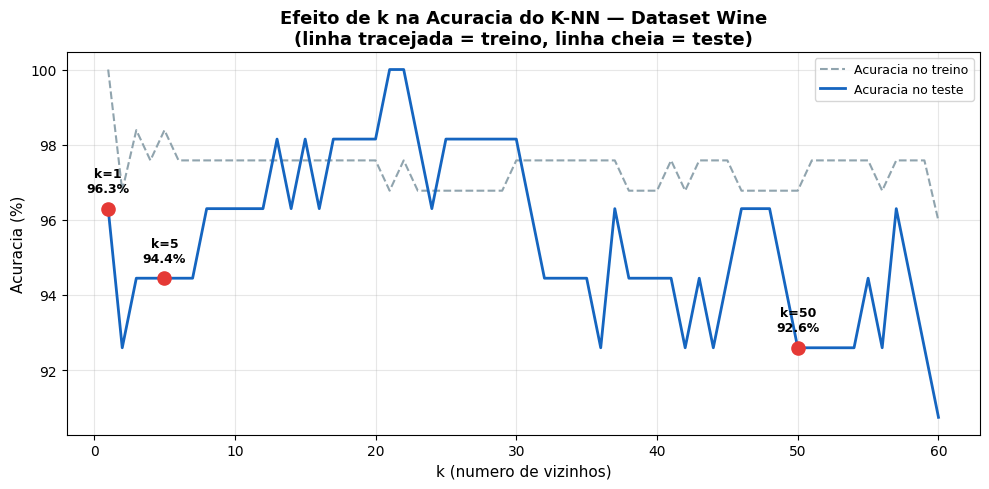

In [10]:
k_range = range(1, 61)
acc_por_k_teste = []
acc_por_k_treino = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc_por_k_treino.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    acc_por_k_teste.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), [a*100 for a in acc_por_k_treino], color='#90A4AE', linewidth=1.5,
         linestyle='--', label='Acuracia no treino')
plt.plot(list(k_range), [a*100 for a in acc_por_k_teste], color='#1565C0', linewidth=2,
         label='Acuracia no teste')
for k in valores_k:
    idx = k - 1
    plt.scatter([k], [acc_por_k_teste[idx]*100], color='#E53935', s=90, zorder=5)
    plt.annotate(f'k={k}\n{acc_por_k_teste[idx]*100:.1f}%', (k, acc_por_k_teste[idx]*100),
                 textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
plt.xlabel('k (numero de vizinhos)', fontsize=11)
plt.ylabel('Acuracia (%)', fontsize=11)
plt.title('Efeito de k na Acuracia do K-NN — Dataset Wine\n(linha tracejada = treino, linha cheia = teste)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Experimento 2 — Controlando o Crescimento da Árvore

Compara-se a árvore de decisão **sem limite de profundidade** (baseline) com uma versão **forçada a ser rasa** (`max_depth=2`).

In [11]:
dt_full = dt_base  # ja treinada na Secao 4, profundidade escolhida livremente pelo algoritmo

dt_shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_shallow.fit(X_train_scaled, y_train)

acc_dt_full_treino = accuracy_score(y_train, dt_full.predict(X_train_scaled))
acc_dt_full_teste = accuracy_score(y_test, dt_full.predict(X_test_scaled))
acc_dt_shallow_treino = accuracy_score(y_train, dt_shallow.predict(X_train_scaled))
acc_dt_shallow_teste = accuracy_score(y_test, dt_shallow.predict(X_test_scaled))

print(f'Arvore SEM limite de profundidade (profundidade real = {dt_full.get_depth()}):')
print(f'  Acuracia treino = {acc_dt_full_treino*100:.2f}%  |  Acuracia teste = {acc_dt_full_teste*100:.2f}%')
print()
print(f'Arvore RASA (max_depth=2, profundidade real = {dt_shallow.get_depth()}):')
print(f'  Acuracia treino = {acc_dt_shallow_treino*100:.2f}%  |  Acuracia teste = {acc_dt_shallow_teste*100:.2f}%')

Arvore SEM limite de profundidade (profundidade real = 4):
  Acuracia treino = 100.00%  |  Acuracia teste = 96.30%

Arvore RASA (max_depth=2, profundidade real = 2):
  Acuracia treino = 93.55%  |  Acuracia teste = 88.89%


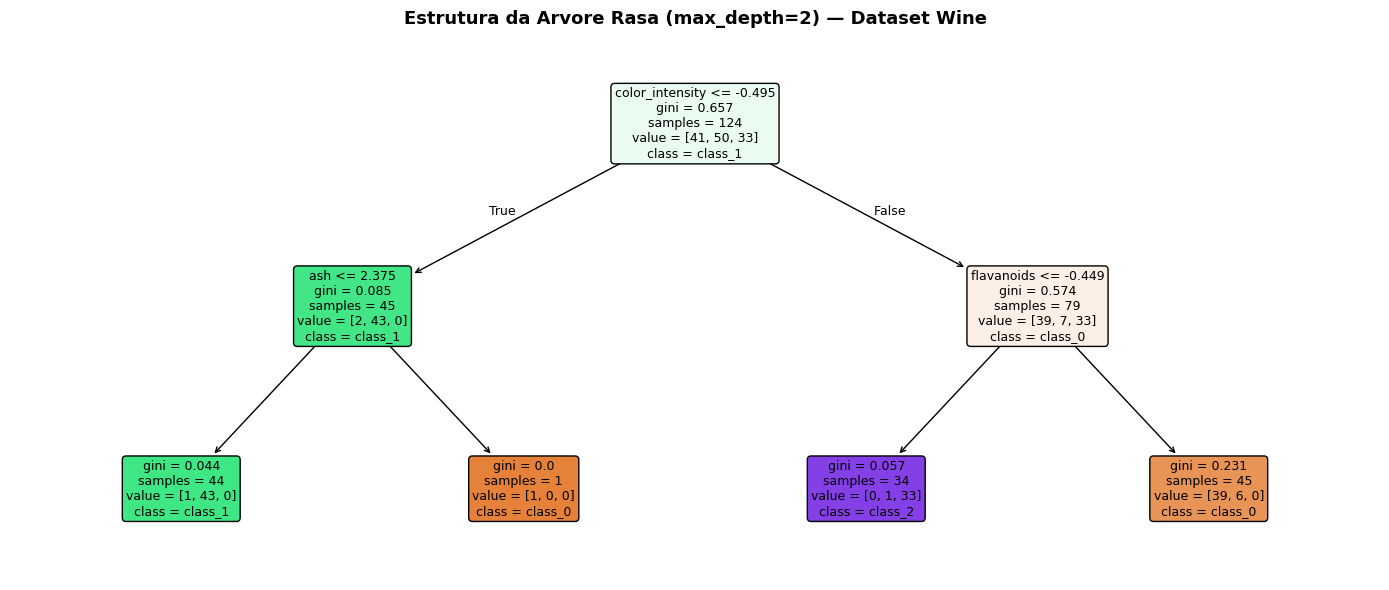

In [12]:
plt.figure(figsize=(14, 6))
plot_tree(
    dt_shallow,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True, rounded=True, fontsize=9
)
plt.title('Estrutura da Arvore Rasa (max_depth=2) — Dataset Wine', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

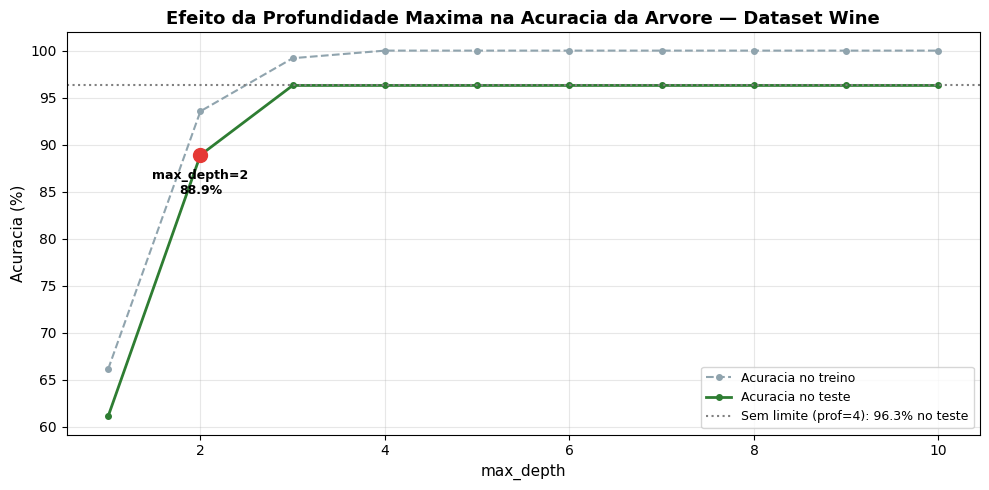

In [13]:
profundidades = list(range(1, 11))
acc_por_prof_teste = []
acc_por_prof_treino = []
for d in profundidades:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    acc_por_prof_treino.append(accuracy_score(y_train, dt.predict(X_train_scaled)))
    acc_por_prof_teste.append(accuracy_score(y_test, dt.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(profundidades, [a*100 for a in acc_por_prof_treino], color='#90A4AE', linewidth=1.5,
         linestyle='--', marker='o', markersize=4, label='Acuracia no treino')
plt.plot(profundidades, [a*100 for a in acc_por_prof_teste], color='#2E7D32', linewidth=2,
         marker='o', markersize=4, label='Acuracia no teste')
plt.axhline(acc_dt_full_teste*100, color='gray', linestyle=':',
            label=f'Sem limite (prof={dt_full.get_depth()}): {acc_dt_full_teste*100:.1f}% no teste')
plt.scatter([2], [acc_por_prof_teste[1]*100], color='#E53935', s=100, zorder=5)
plt.annotate(f'max_depth=2\n{acc_por_prof_teste[1]*100:.1f}%', (2, acc_por_prof_teste[1]*100),
             textcoords='offset points', xytext=(0, -28), ha='center', fontsize=9, fontweight='bold')
plt.xlabel('max_depth', fontsize=11)
plt.ylabel('Acuracia (%)', fontsize=11)
plt.title('Efeito da Profundidade Maxima na Acuracia da Arvore — Dataset Wine',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7. Experimento 3 — A "Ingenuidade" do Naive Bayes

O Naive Bayes foi treinado **sem nenhum ajuste de hiperparâmetro**. Avalia-se sua matriz de confusão e compara-se o **tempo de treinamento** dos três modelos para discutir sua eficiência.

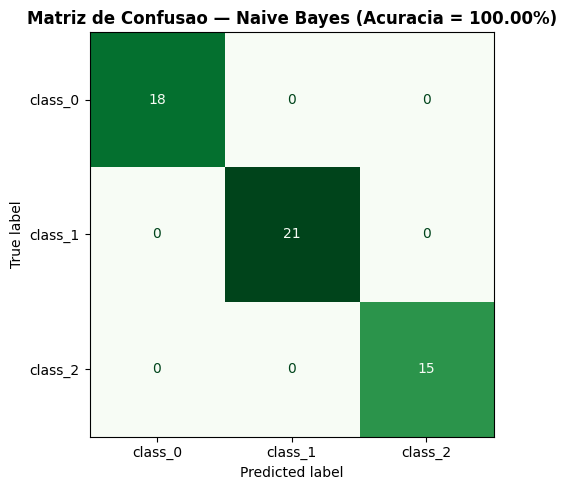

In [14]:
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title(f'Matriz de Confusao — Naive Bayes (Acuracia = {acc_nb_base*100:.2f}%)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
n_repeticoes = 200
tempos = {}

modelos_tempo = {
    'K-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Arvore de Decisao': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

for nome, modelo in modelos_tempo.items():
    inicio = time.perf_counter()
    for _ in range(n_repeticoes):
        modelo.fit(X_train_scaled, y_train)
    fim = time.perf_counter()
    tempos[nome] = (fim - inicio) / n_repeticoes * 1000  # ms por treino

print(f'Tempo medio de treinamento por modelo (media de {n_repeticoes} execucoes):')
for nome, t in tempos.items():
    print(f'  {nome:<20}: {t:.4f} ms')

Tempo medio de treinamento por modelo (media de 200 execucoes):
  K-NN (k=5)          : 0.5026 ms
  Arvore de Decisao   : 1.1367 ms
  Naive Bayes         : 0.6690 ms


### 8. Painel Comparativo Final

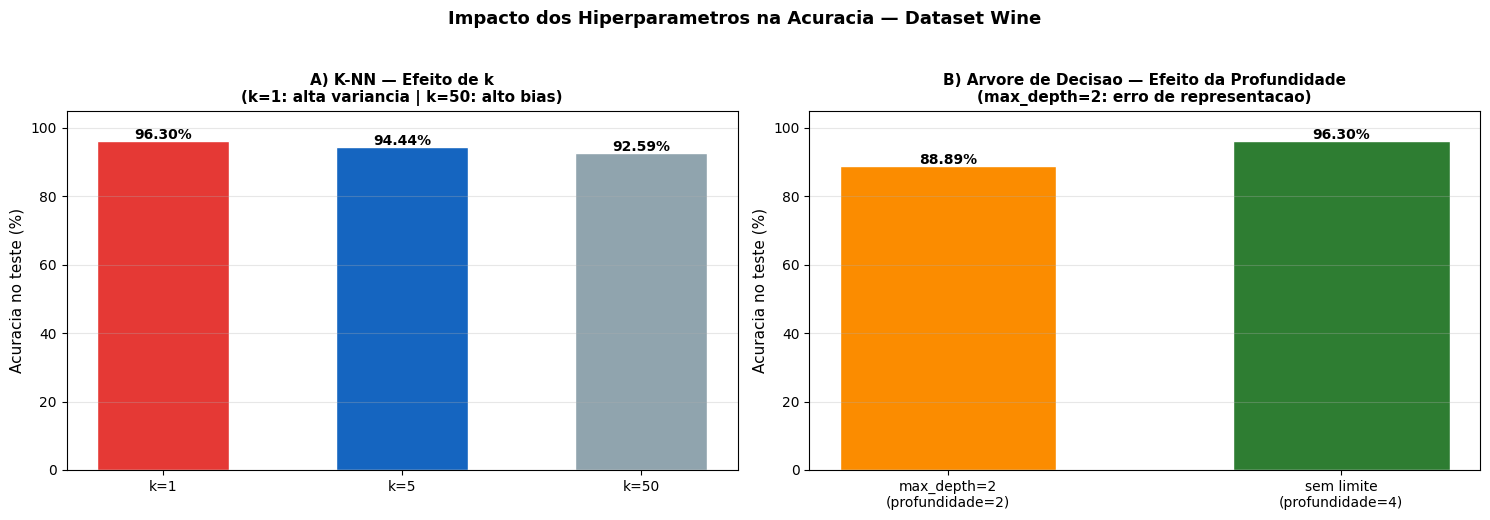

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
labels_knn = ['k=1', 'k=5', 'k=50']
valores_knn = [acc_por_k_teste[0], acc_por_k_teste[4], acc_por_k_teste[49]]
cores_knn = ['#E53935', '#1565C0', '#90A4AE']
bars = ax.bar(labels_knn, [v*100 for v in valores_knn], color=cores_knn, edgecolor='white', width=0.55)
for bar, val in zip(bars, valores_knn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val*100:.2f}%',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Acuracia no teste (%)', fontsize=11)
ax.set_title('A) K-NN — Efeito de k\n(k=1: alta variancia | k=50: alto bias)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
labels_dt = [f'max_depth=2\n(profundidade={dt_shallow.get_depth()})',
             f'sem limite\n(profundidade={dt_full.get_depth()})']
valores_dt = [acc_dt_shallow_teste, acc_dt_full_teste]
cores_dt = ['#FB8C00', '#2E7D32']
bars2 = ax.bar(labels_dt, [v*100 for v in valores_dt], color=cores_dt, edgecolor='white', width=0.55)
for bar, val in zip(bars2, valores_dt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val*100:.2f}%',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Acuracia no teste (%)', fontsize=11)
ax.set_title('B) Arvore de Decisao — Efeito da Profundidade\n(max_depth=2: erro de representacao)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Impacto dos Hiperparametros na Acuracia — Dataset Wine',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 9. Respostas às Perguntas

#### Questão 1 — O Efeito do K no K-NN (k=1, k=5, k=50)

Os resultados obtidos foram:

| k | Acurácia Treino | Acurácia Teste |
|---|---|---|
| **1** | 100,00% | 96,30% |
| **5** | 98,39% | 94,44% |
| **50** | 96,77% | 92,59% |

Observa-se que a acurácia no teste **caiu progressivamente** à medida que k aumentou (96,30% → 94,44% → 92,59%). O comportamento se explica pelos dois extremos do compromisso **Bias-Variância**:

- **k=1 (Variância alta):** o modelo classifica cada ponto pelo seu único vizinho mais próximo, o que faz a acurácia de treino atingir **100%** — a fronteira de decisão se molda a cada ruído e particularidade do conjunto de treino (inclusive outliers). Isso é a assinatura clássica de **alta variância**: o modelo é extremamente sensível aos dados específicos de treino, e pequenas mudanças no conjunto de treino gerariam fronteiras de decisão bem diferentes. Ainda assim, no Wine (classes quimicamente bem separáveis), esse ajuste fino generalizou razoavelmente bem para o teste (96,30%), mas o **gap treino-teste** já aparece (3,7 pontos).
- **k=50 (Bias alto):** com 50 vizinhos (quase um terço do conjunto de treino, que tem 124 amostras), a votação passa a ser dominada pela classe mais frequente na vizinhança ampla, "borrando" as fronteiras entre vinícolas próximas quimicamente. O resultado é um modelo **excessivamente simplificado (underfitting)**: note que a acurácia caiu não só no teste, mas também **no treino** (96,77%, a pior das três). Isso é a assinatura de **alto bias** — o modelo é rígido demais e nem consegue representar bem os próprios dados de treino, pois generaliza demais para além da vizinhança realmente relevante de cada ponto.
- **k=5** fica no meio-termo, equilibrando as duas forças, o que costuma ser o objetivo prático ao ajustar k (idealmente via validação cruzada).

#### Questão 2 — Controlando o Crescimento da Árvore (max_depth=2)

| Configuração | Profundidade real | Acurácia Treino | Acurácia Teste |
|---|---|---|---|
| **Sem limite** | 4 | 100,00% | 96,30% |
| **max_depth=2** | 2 | 93,55% | 88,89% |

A acurácia **diminuiu** em ambos os conjuntos ao forçar a árvore a ser rasa (treino: 100% → 93,55%; teste: 96,30% → 88,89%).

Isso acontece por causa do **erro de representação (bias/underfitting)**: uma árvore com profundidade 2 permite, no máximo, 4 folhas — ou seja, no máximo 4 regiões de decisão construídas a partir de apenas duas perguntas sequenciais sobre os atributos químicos. O dataset Wine tem 3 classes cujas fronteiras reais dependem de combinações mais sutis de atributos (por exemplo, `flavanoids`, `color_intensity`, `proline` e `od280/od315` interagindo de formas distintas para cada vinícola). Ao limitar a árvore a apenas 2 níveis, o modelo é **forçado a simplificar demais a fronteira de decisão real**, cometendo erros sistemáticos que nem a poda ideal dos dados de treino consegue evitar — daí a queda de acurácia acontecer tanto no treino quanto no teste, e não apenas no teste (o que seria sinal de overfitting, não de erro de representação). Uma árvore rasa demais **não tem capacidade suficiente (capacidade de representação)** para capturar a complexidade do problema, mesmo que os dados de treino estivessem perfeitamente disponíveis para ela "decorar".

#### Questão 3 — A "Ingenuidade" de Bayes

Sim: o Naive Bayes atingiu **100% de acurácia no teste** sem qualquer ajuste de hiperparâmetro, superando inclusive o K-NN e a Árvore de Decisão baseline nesta rodada, e seu treinamento foi um dos mais rápidos entre os três modelos (tabela da Seção 7).

O motivo é a **suposição de independência condicional** que dá nome ao algoritmo ("naive" = ingênuo): o modelo assume que, dada a classe, cada atributo químico (teor alcoólico, flavanoides, prolina etc.) é gerado de forma **independente** dos demais, seguindo uma distribuição Gaussiana própria por classe. Essa simplificação — mesmo sendo tecnicamente "errada" na prática, já que atributos químicos de um vinho certamente se correlacionam entre si, como visto na matriz de correlação da Seção 2 — traz duas vantagens práticas diretas:

1. **Eficiência computacional:** em vez de estimar uma matriz de covariância completa entre os 13 atributos (que cresce quadraticamente com o número de atributos), o Naive Bayes Gaussiano só precisa estimar **média e variância de cada atributo, separadamente, por classe**. Isso é O(atributos × classes) em vez de O(atributos² × classes), o que explica o treinamento praticamente instantâneo mesmo com múltiplos atributos numéricos.
2. **Poucos parâmetros, baixa variância:** por depender de estimativas simples (médias e variâncias), o modelo tem pouquíssimos parâmetros a ajustar, o que o torna menos propenso a overfitting em conjuntos de dados pequenos como o Wine (apenas 178 amostras) — o modelo já "acerta o suficiente" com poucos dados de treino, dispensando busca de hiperparâmetros.

Na prática, quando os atributos realmente carregam informação discriminativa forte por classe (como no Wine, onde compostos químicos específicos marcam cada vinícola), a suposição ingênua de independência acaba não custando muita precisão — mesmo violada, ela ainda aponta na direção certa para a classificação final.

### 10. Conclusão

A implementação dos três classificadores no Dataset Wine evidenciou, na prática, como cada algoritmo lida com o compromisso entre simplicidade e capacidade de representação:

- O **K-NN** mostrou de forma direta o dilema **Bias-Variância**: k pequeno (k=1) memoriza o treino (variância alta, 100% de acurácia de treino), enquanto k grande (k=50) borra as fronteiras entre classes e perde acurácia mesmo no treino (bias alto). A melhor acurácia de teste (96,30%) ocorreu com o k mais baixo testado, mas o menor *gap* treino-teste não necessariamente ocorre no mesmo ponto — reforçando que k deve ser escolhido por validação, não apenas pela acurácia de treino.

- A **Árvore de Decisão** confirmou que restringir `max_depth` introduz **erro de representação**: com apenas 2 níveis de profundidade, o modelo carece de capacidade para capturar as fronteiras reais entre as 3 vinícolas, e a acurácia caiu tanto no treino quanto no teste (underfitting clássico), contra uma árvore que cresceu livremente até profundidade 4 e atingiu 96,30% no teste.

- O **Naive Bayes**, apesar de sua suposição "ingênua" de independência entre atributos, foi o classificador de melhor desempenho nesta rodada (100% de acurácia) e um dos mais rápidos de treinar — resultado de estimar apenas média e variância por atributo e por classe, em vez de modelar todas as interações entre os 13 atributos químicos.

No conjunto, o experimento reforça que **acurácia mais alta no treino não garante melhor generalização**, e que a escolha de hiperparâmetros (k no K-NN, profundidade na árvore) deve equilibrar a complexidade do modelo com a complexidade real do problema — algo que o Naive Bayes contorna elegantemente ao assumir uma estrutura probabilística simples que, neste dataset, se mostrou adequada.